In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

- torch: core pytorch lib for tensor operations
- torch.nn: neural network modules(layers,loss function)
- torch.optim: optimization algo (adam)
- dataloader: load dataset in batches
- datasets, transforms: build in datasets and preprocessing tools
- matplotlib: for visualizing results
- numpy: numerical operations
- defaultdict: for storing training history 

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Laptop GPU


In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device:{device}")

torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

using device:cuda


- checking if gpu is avaible for faster training
- setting random seeds to ensure reproducible results

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5),(0.5))
])

train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download= True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

batch_size= 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"training samples: {len(train_dataset)}")
print(f"test samples: {len(test_dataset)}")
print(f"batch: {batch_size}")
print(f"no of batches: {len(train_loader)}")

Using downloaded and verified file: ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz
Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100.0%


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100.0%

Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

training samples: 60000
test samples: 10000
batch: 64
no of batches: 938


- Totensor(): converts image(28x28 pxels) to Pytorch tensors and the scale pixel values from [0,255] to [0,1]
- normalize(): standardizes data to mean =0.5, std = 0.5 resulting in range[-1,1]
- dataloader: batches data for effcient training, shuffles trainig data to prevent learning order patterns
- fashin mnist has 60,000 trainign and 10,000 test images across 10 classes

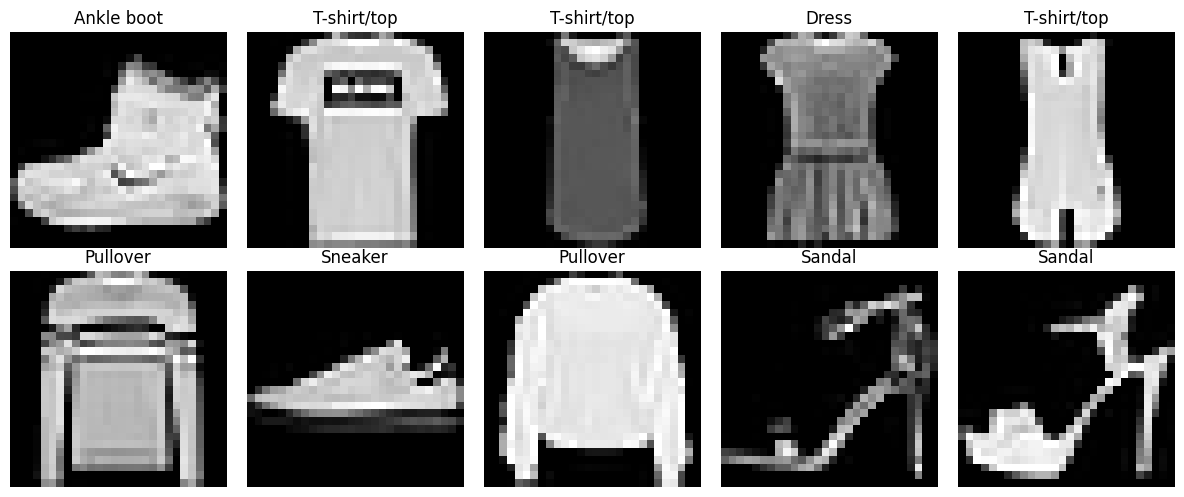

In [5]:
fig, axes  = plt.subplots(2,5, figsize=(12,5))
for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]
    image = image.squeeze().numpy() * 0.5 +0.5
    ax.imshow(image, cmap='gray')
    ax.set_title(f'{class_names[label]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

- display first 10 training images
- denormalizes images back to [0,1] from [0,255] for normal human to visualize
- this helps to verify if the data is loaded correctly and bring the images to a normalize range to be understand by human visually 

In [6]:
class fashionMNISTNet(nn.Module):
    def __init__(self,input_size = 784, hidden_sizes =[256,128,64], num_classes=10):
        super(fashionMNISTNet, self).__init__()

        layers =[]
        prev_size = input_size

        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            prev_size = hidden_size

        layers.append(nn.Linear(prev_size, num_classes))

        self.network = nn.Sequential(*layers)

    def forward(self,X):
        x = X.view(X.size(0),-1)
        return self.network(x)

model = fashionMNISTNet(hidden_sizes=[256,128,64]).to(device)
print(model)
print(f"total parameters: {sum(p.numel() for p in model.parameters())}")

fashionMNISTNet(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)
total parameters: 242762


- architecture: 
    - input (784) -> hidden1 (256) -> RelU ->hidden2(128) -> Relu -> hidden3(64) -> Relu -> output(10)
- nn.linear: fully connected layer (output = input* weight+ bias)
- ReLU: Rectified Linear Unit activation: f(x)=max(0,x),introduces non-linearity
- no activation on output: raw scores(logits) for each class used with cross entropy loss
- view(): reshaping the image 28x28 into 784-dimensional vector

In [7]:
criterion = nn.CrossEntropyLoss()

learning_rate = 0.001
optimizer = optim.Adam(model.parameters(),lr= learning_rate)

print(f"learning rate: {learning_rate}")

learning rate: 0.001


- CrossEntropyLoss: this combines softmax + negative loglikehood, suitable for multi-class classification
    - converts logits to probabilities 
    - penalizes incorrect predictions
- adam optimizer: adaptive learning rate optimizer
    - combines momentum and RMSporp
    - generally faster convergence than SGD
    - automatically adjusts learning rates for each parameter

In [8]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss =0.0
    correct =0
    total=0

    for batch_idx,(images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss+=loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct +=(predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc =100*correct/total

    return epoch_loss,epoch_acc

- model.train(): enable training mode(affects dropout, batchnorm if used)
- forward pass: input -> network -> output predictions
- loss calculation: diff between predictions and the true value
- backward pass:
    - optimizer.zero_grad(): clear old gradients(pytorch accumulates them)
    - loss.backward(): computes gradients via backpropagation
    - optimzer.step(): updates weight using gradients
- gradient updates: weights are adjusted to minimize loss
    - weight_new = weight_old - learning_rate * gradient 

In [9]:
def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss =0.0
    correct =0
    total =0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss= criterion(outputs, labels)

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_loss = running_loss / len(test_loader)
    test_acc = 100 * correct / total
    
    return test_loss, test_acc

- model.eval(): disables random turning off of some neurons, uses current batch statistics that delivery consistent behaviour
- touch.no_grad(): saves memory by not tracking gradients
- only forward pass is performed
- compute loss and accuracy on test dataset without weigths being updated

In [10]:
num_epochs = 20

history = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

print("Start training")
print("-" * 60)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    print("-" * 60)

print("Training completed!")

Start training
------------------------------------------------------------
Epoch [1/20]
  Train Loss: 0.5247, Train Acc: 80.94%
  Test Loss: 0.4486, Test Acc: 83.25%
------------------------------------------------------------
Epoch [2/20]
  Train Loss: 0.3777, Train Acc: 86.15%
  Test Loss: 0.3757, Test Acc: 86.57%
------------------------------------------------------------
Epoch [3/20]
  Train Loss: 0.3386, Train Acc: 87.48%
  Test Loss: 0.3879, Test Acc: 85.61%
------------------------------------------------------------
Epoch [4/20]
  Train Loss: 0.3117, Train Acc: 88.42%
  Test Loss: 0.3723, Test Acc: 86.63%
------------------------------------------------------------
Epoch [5/20]
  Train Loss: 0.2921, Train Acc: 89.27%
  Test Loss: 0.3658, Test Acc: 86.95%
------------------------------------------------------------
Epoch [6/20]
  Train Loss: 0.2797, Train Acc: 89.49%
  Test Loss: 0.3556, Test Acc: 87.44%
------------------------------------------------------------
Epoch [7/20]

- train model for specific number of epochs
- each epoch processes entire training dataset once
- after each epoch, evaluates on test set to monitor generalization
- this monitor both loss (how wrng predictions are) and accuracy(% correct predictions) 

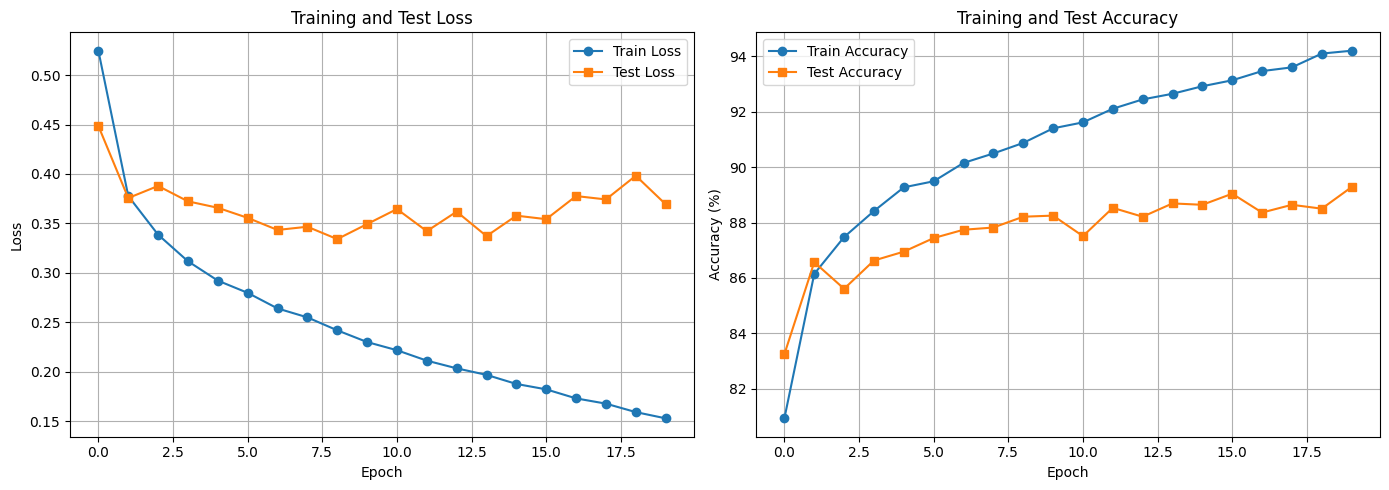


Final Results:
Train Accuracy: 94.20%
Test Accuracy: 89.28%


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', marker='o')
ax1.plot(history['test_loss'], label='Test Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(history['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history['test_acc'], label='Test Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal Results:")
print(f"Train Accuracy: {history['train_acc'][-1]:.2f}%")
print(f"Test Accuracy: {history['test_acc'][-1]:.2f}%")

- visualize how loss decrease and accuracy increase over epochs 
- helps :
    - convergence: when stablize
    - overfitting: when train accuracy > test accuracy
    - underfitting: when both accuracies are low 

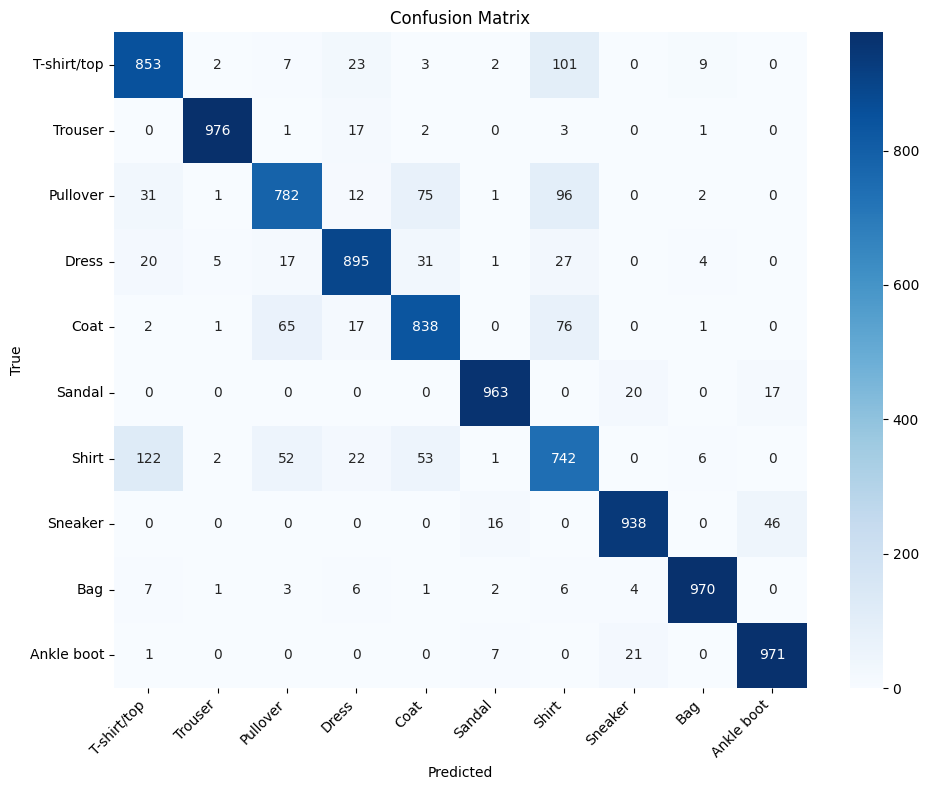


Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.85      0.84      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.84      0.78      0.81      1000
       Dress       0.90      0.90      0.90      1000
        Coat       0.84      0.84      0.84      1000
      Sandal       0.97      0.96      0.97      1000
       Shirt       0.71      0.74      0.72      1000
     Sneaker       0.95      0.94      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.94      0.97      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [12]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

- confusion matrix: show which classes are confused with each other
- classification report: per-class precision, recall and F1-score
- help identify which clothing items are hardes to classify

In [13]:
print("="*70)
print("EXPLANATION: Forward Pass, Backward Pass, and Gradient Updates")
print("="*70)

explanation = """
 Conceptual explanation of the three key training phases:
1. FORWARD PASS:
   - Input image (28×28) is flattened to 784-dimensional vector
   - Data flows through each layer: Input → Hidden1 → Hidden2 → Hidden3 → Output
   - At each layer:
     * Linear transformation: z = W·x + b
     * Activation function (ReLU): a = max(0, z)
   - Output layer produces 10 logits (raw scores for each class)
   - Loss is computed by comparing predictions with true labels

2. BACKWARD PASS (Backpropagation):
   - Computes how much each weight contributed to the error
   - Uses chain rule to propagate gradients from output to input
   - For each layer (starting from output):
     * Calculate gradient of loss w.r.t. layer outputs
     * Calculate gradient w.r.t. layer weights
     * Pass gradient to previous layer
   - Results in ∂Loss/∂W for every weight in the network

3. GRADIENT UPDATES:
   - Optimizer uses computed gradients to update weights
   - Adam optimizer formula (simplified):
     * m_t = β₁·m_(t-1) + (1-β₁)·gradient
     * v_t = β₂·v_(t-1) + (1-β₂)·gradient²
     * W_new = W_old - learning_rate · m_t / √(v_t + ε)
   - Weights move in direction that reduces loss
   - Process repeats for multiple epochs until convergence
"""

print(explanation)

EXPLANATION: Forward Pass, Backward Pass, and Gradient Updates

 Conceptual explanation of the three key training phases:
1. FORWARD PASS:
   - Input image (28×28) is flattened to 784-dimensional vector
   - Data flows through each layer: Input → Hidden1 → Hidden2 → Hidden3 → Output
   - At each layer:
     * Linear transformation: z = W·x + b
     * Activation function (ReLU): a = max(0, z)
   - Output layer produces 10 logits (raw scores for each class)
   - Loss is computed by comparing predictions with true labels

2. BACKWARD PASS (Backpropagation):
   - Computes how much each weight contributed to the error
   - Uses chain rule to propagate gradients from output to input
   - For each layer (starting from output):
     * Calculate gradient of loss w.r.t. layer outputs
     * Calculate gradient w.r.t. layer weights
     * Pass gradient to previous layer
   - Results in ∂Loss/∂W for every weight in the network

3. GRADIENT UPDATES:
   - Optimizer uses computed gradients to update w

# advanced tasks

- Advanced Task 1: Network Depth and Width Experiments

EXPERIMENT: Network Depth and Width

Training: 1 Hidden Layer [128]
  Final Test Accuracy: 88.35%
  Parameters: 101,770

Training: 3 Hidden Layers [256, 128, 64]
  Final Test Accuracy: 88.56%
  Parameters: 242,762

Training: 5 Hidden Layers [512, 256, 128, 64, 32]
  Final Test Accuracy: 88.71%
  Parameters: 576,810

Training: Wide Network [512, 512, 512]
  Final Test Accuracy: 89.06%
  Parameters: 932,362

Training: Narrow Network [64, 64, 64]
  Final Test Accuracy: 87.50%
  Parameters: 59,210


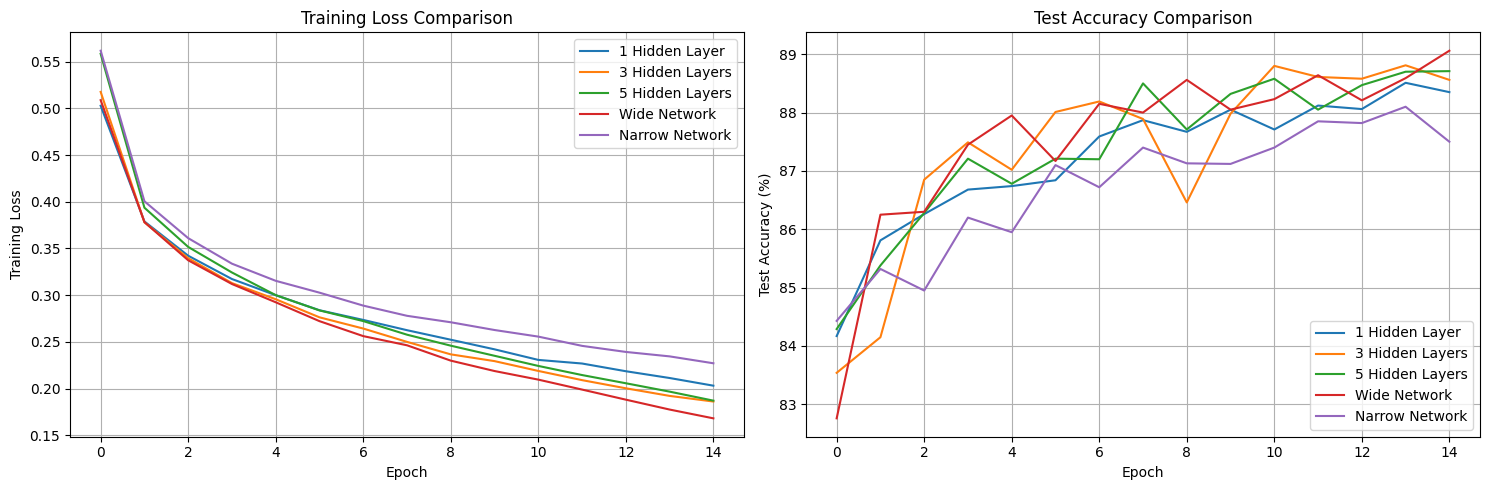


SUMMARY: Depth vs Width Trade-offs
1 Hidden Layer      : Acc=88.35%, Params=101,770
3 Hidden Layers     : Acc=88.56%, Params=242,762
5 Hidden Layers     : Acc=88.71%, Params=576,810
Wide Network        : Acc=89.06%, Params=932,362
Narrow Network      : Acc=87.50%, Params=59,210


In [14]:
architectures = {
    '1 Hidden Layer': [128],
    '3 Hidden Layers': [256, 128, 64],
    '5 Hidden Layers': [512, 256, 128, 64, 32],
    'Wide Network': [512, 512, 512],
    'Narrow Network': [64, 64, 64]
}

results = {}
epochs_experiment = 15

print("="*70)
print("EXPERIMENT: Network Depth and Width")
print("="*70)

for name, hidden_sizes in architectures.items():
    print(f"\nTraining: {name} {hidden_sizes}")
    
    model_exp = fashionMNISTNet(hidden_sizes=hidden_sizes).to(device)
    optimizer_exp = optim.Adam(model_exp.parameters(), lr=0.001)
    
    train_losses = []
    test_accs = []
    
    for epoch in range(epochs_experiment):
        train_loss, _ = train_epoch(model_exp, train_loader, criterion, optimizer_exp, device)
        _, test_acc = evaluate(model_exp, test_loader, criterion, device)
        train_losses.append(train_loss)
        test_accs.append(test_acc)
    
    results[name] = {
        'train_losses': train_losses,
        'test_accs': test_accs,
        'final_acc': test_accs[-1],
        'params': sum(p.numel() for p in model_exp.parameters())
    }
    
    print(f"  Final Test Accuracy: {test_accs[-1]:.2f}%")
    print(f"  Parameters: {results[name]['params']:,}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for name in architectures.keys():
    ax1.plot(results[name]['train_losses'], label=name)
    ax2.plot(results[name]['test_accs'], label=name)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Test Accuracy Comparison')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("SUMMARY: Depth vs Width Trade-offs")
print("="*70)
for name, res in results.items():
    print(f"{name:20s}: Acc={res['final_acc']:.2f}%, Params={res['params']:,}")

- 5 different architectures.
- observation typically include:
    - deeper network learn more complex features but risk overfitting
    - wider netwrk have more capacity but will be slower
    - too shallow leading to underfitting
    - too deep leading to overfitting/ vanashing gradients 

# Advanced Task 2: Activation Function Study

EXPERIMENT: Activation Functions

Training with RELU activation...
  Final Accuracy: 88.43%
  Training Time: 125.87s

Training with SIGMOID activation...
  Final Accuracy: 87.90%
  Training Time: 117.01s

Training with TANH activation...
  Final Accuracy: 86.80%
  Training Time: 123.95s

Training with LEAKY_RELU activation...
  Final Accuracy: 88.23%
  Training Time: 108.22s


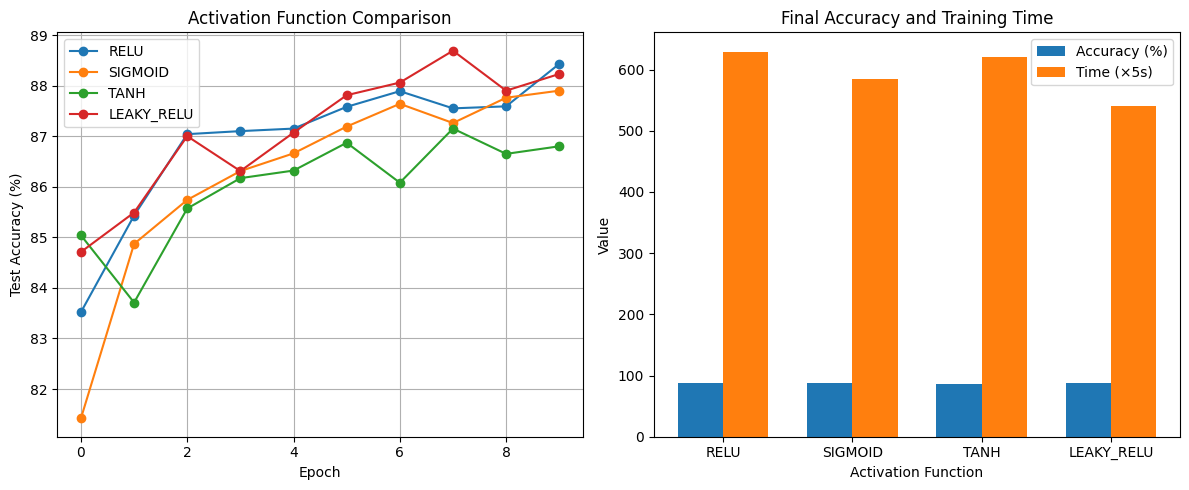


WHY SOME ACTIVATIONS PERFORM BETTER:

1. ReLU (Best for deep networks):
   - No vanishing gradient problem
   - Computationally efficient
   - Sparse activation (many zeros)
   - Can suffer from "dying ReLU" problem

2. Sigmoid (Worst for deep networks):
   - Saturates (gradients → 0) for large inputs
   - Vanishing gradient in deep networks
   - Outputs in (0,1) range
   - Historically used, now mostly replaced

3. Tanh (Better than Sigmoid):
   - Zero-centered outputs (-1, 1)
   - Still suffers from vanishing gradients
   - Slightly better than Sigmoid

4. Leaky ReLU (Improved ReLU):
   - Solves dying ReLU problem
   - Small negative slope (0.01) when x < 0
   - Similar performance to ReLU, sometimes better

EXPECTED RESULTS:
- ReLU/Leaky ReLU: Fastest convergence, highest accuracy
- Tanh: Moderate performance
- Sigmoid: Slowest, lowest accuracy (especially in deep networks)



In [15]:
class FlexibleNet(nn.Module):
    def __init__(self, hidden_sizes=[256, 128, 64], activation='relu'):
        super(FlexibleNet, self).__init__()
        
        layers = []
        prev_size = 784
        
        if activation == 'relu':
            act = nn.ReLU()
        elif activation == 'sigmoid':
            act = nn.Sigmoid()
        elif activation == 'tanh':
            act = nn.Tanh()
        elif activation == 'leaky_relu':
            act = nn.LeakyReLU(0.01)
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(act)
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, 10))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)

activations = ['relu', 'sigmoid', 'tanh', 'leaky_relu']
activation_results = {}

print("="*70)
print("EXPERIMENT: Activation Functions")
print("="*70)

import time

for act_name in activations:
    print(f"\nTraining with {act_name.upper()} activation...")
    
    model_act = FlexibleNet(activation=act_name).to(device)
    optimizer_act = optim.Adam(model_act.parameters(), lr=0.001)
    
    start_time = time.time()
    test_accs = []
    
    for epoch in range(10):  
        train_epoch(model_act, train_loader, criterion, optimizer_act, device)
        _, test_acc = evaluate(model_act, test_loader, criterion, device)
        test_accs.append(test_acc)
    
    training_time = time.time() - start_time
    
    activation_results[act_name] = {
        'test_accs': test_accs,
        'final_acc': test_accs[-1],
        'time': training_time
    }
    
    print(f"  Final Accuracy: {test_accs[-1]:.2f}%")
    print(f"  Training Time: {training_time:.2f}s")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for act_name in activations:
    plt.plot(activation_results[act_name]['test_accs'], label=act_name.upper(), marker='o')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Activation Function Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
act_names = [a.upper() for a in activations]
final_accs = [activation_results[a]['final_acc'] for a in activations]
times = [activation_results[a]['time'] for a in activations]

x = np.arange(len(activations))
width = 0.35

plt.bar(x - width/2, final_accs, width, label='Accuracy (%)')
plt.bar(x + width/2, np.array(times)*5, width, label='Time (×5s)')
plt.xlabel('Activation Function')
plt.ylabel('Value')
plt.title('Final Accuracy and Training Time')
plt.xticks(x, act_names)
plt.legend()

plt.tight_layout()
plt.show()

# Explanation
print("\n" + "="*70)
print("WHY SOME ACTIVATIONS PERFORM BETTER:")
print("="*70)
activation_explanation = """
1. ReLU (Best for deep networks):
   - No vanishing gradient problem
   - Computationally efficient
   - Sparse activation (many zeros)
   - Can suffer from "dying ReLU" problem

2. Sigmoid (Worst for deep networks):
   - Saturates (gradients → 0) for large inputs
   - Vanishing gradient in deep networks
   - Outputs in (0,1) range
   - Historically used, now mostly replaced

3. Tanh (Better than Sigmoid):
   - Zero-centered outputs (-1, 1)
   - Still suffers from vanishing gradients
   - Slightly better than Sigmoid

4. Leaky ReLU (Improved ReLU):
   - Solves dying ReLU problem
   - Small negative slope (0.01) when x < 0
   - Similar performance to ReLU, sometimes better

EXPECTED RESULTS:
- ReLU/Leaky ReLU: Fastest convergence, highest accuracy
- Tanh: Moderate performance
- Sigmoid: Slowest, lowest accuracy (especially in deep networks)
"""
print(activation_explanation)

- comparing 4 acitvation function
    - relu avoids vanishing gradients, enabling deep network
    - sigmoid/tanH saturate, making gradient-based learning difficult
    - leaky relu prevent dead neurons

# Advanced Task 3: Visualization of Hidden Layer Activations

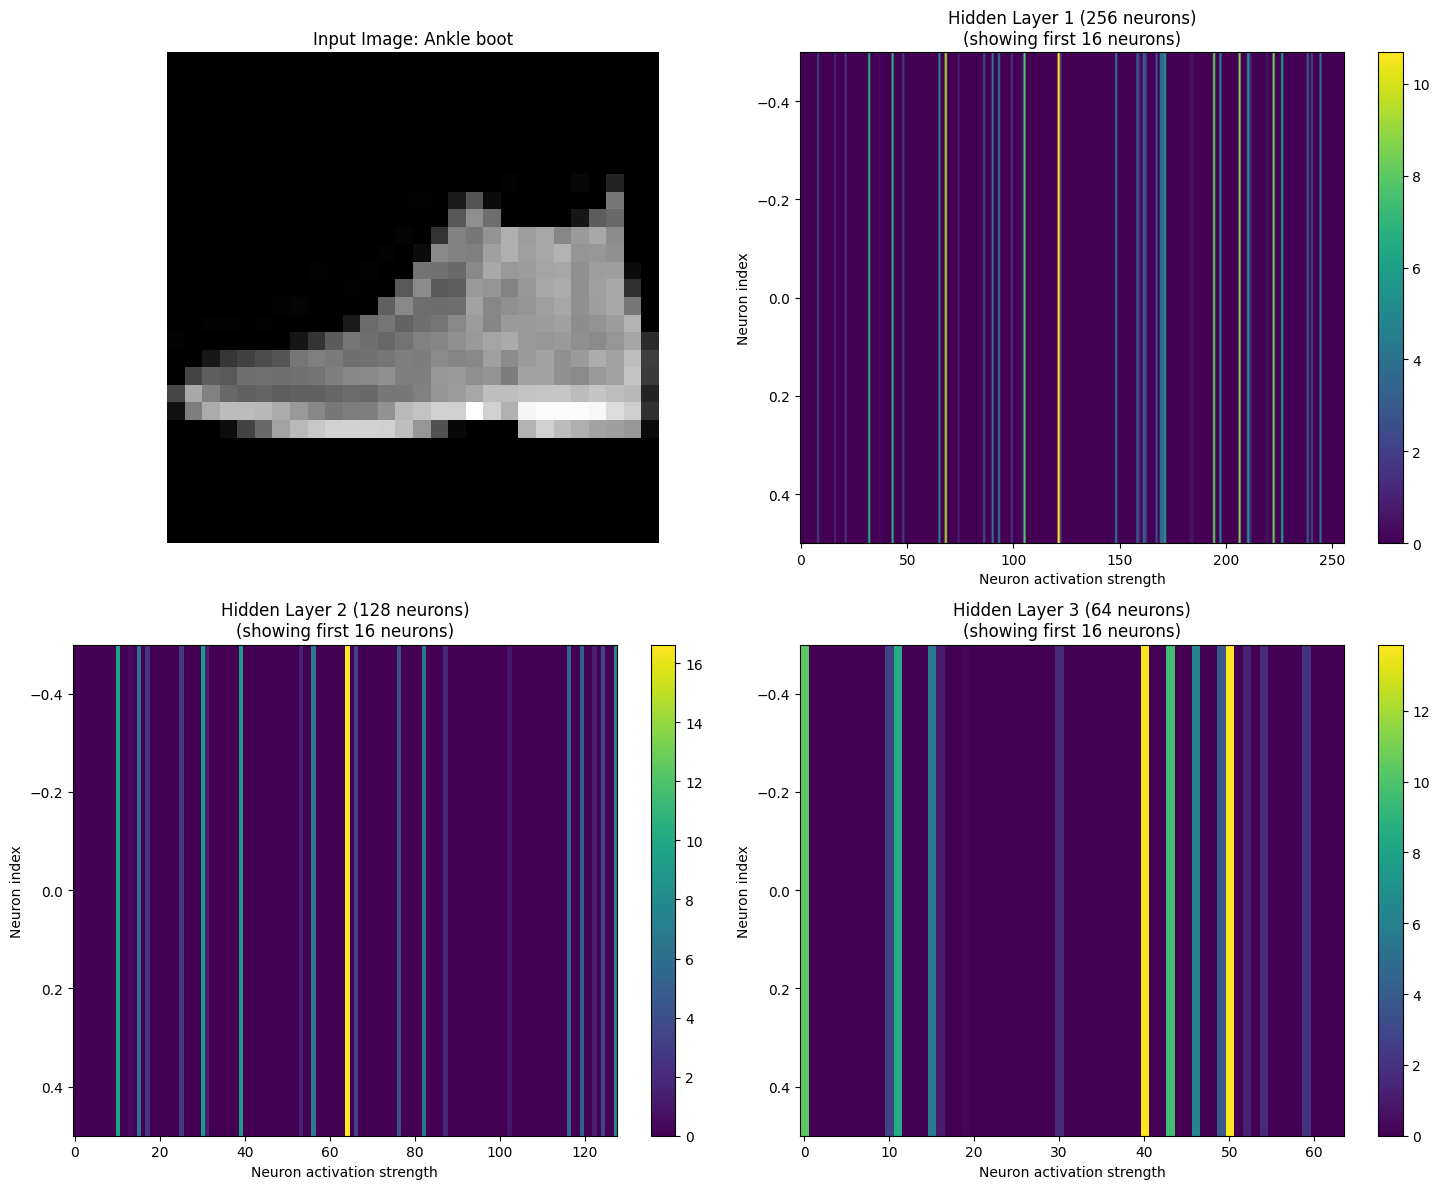

HIDDEN LAYER ACTIVATION ANALYSIS

Hidden Layer 1 (256 neurons):
  Shape: (1, 256)
  Active neurons (>0): 40/256 (15.6%)
  Mean activation: 0.5861
  Max activation: 10.6912
  Sparsity (zeros): 216/256 (84.4%)

Hidden Layer 2 (128 neurons):
  Shape: (1, 128)
  Active neurons (>0): 22/128 (17.2%)
  Mean activation: 0.8358
  Max activation: 16.6312
  Sparsity (zeros): 106/128 (82.8%)

Hidden Layer 3 (64 neurons):
  Shape: (1, 64)
  Active neurons (>0): 15/64 (23.4%)
  Mean activation: 1.2935
  Max activation: 13.8666
  Sparsity (zeros): 49/64 (76.6%)

FEATURE TRANSFORMATION EXPLANATION:

How features are transformed at each layer:

Layer 1 (256 neurons):
- Learns low-level features (edges, textures, simple patterns)
- High dimensionality captures various basic features
- Many active neurons indicate rich feature representation

Layer 2 (128 neurons):
- Combines low-level features into mid-level features
- May detect parts of clothing (collars, sleeves, patterns)
- Dimensionality reduction 

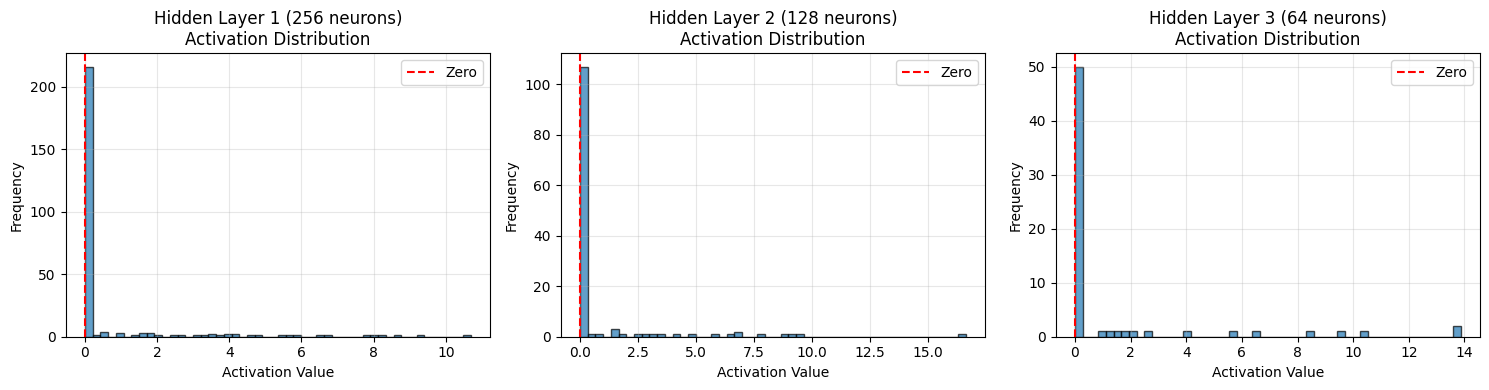

In [17]:
def get_layer_activations(model, input_tensor):
    activations = []
    x = input_tensor.view(input_tensor.size(0), -1)
    
    for layer in model.network:
        x = layer(x)
        if isinstance(layer, (nn.ReLU, nn.Sigmoid, nn.Tanh, nn.LeakyReLU)):
            activations.append(x.detach().cpu().numpy())
    
    return activations

sample_image, sample_label = test_dataset[0]
sample_image_batch = sample_image.unsqueeze(0).to(device)

model.eval()
activations = get_layer_activations(model, sample_image_batch)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

ax = axes[0, 0]
img_display = sample_image.squeeze().numpy() * 0.5 + 0.5
ax.imshow(img_display, cmap='gray')
ax.set_title(f'Input Image: {class_names[sample_label]}')
ax.axis('off')

layer_names = ['Hidden Layer 1 (256 neurons)', 
               'Hidden Layer 2 (128 neurons)', 
               'Hidden Layer 3 (64 neurons)']

for idx, (activation, name) in enumerate(zip(activations, layer_names)):
    ax = axes[(idx+1)//2, (idx+1)%2]
    
    # Reshape activation for visualization
    act_2d = activation[0].reshape(1, -1)
    
    im = ax.imshow(act_2d[:16, :], cmap='viridis', aspect='auto')
    ax.set_title(f'{name}\n(showing first 16 neurons)')
    ax.set_xlabel('Neuron activation strength')
    ax.set_ylabel('Neuron index')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

print("="*70)
print("HIDDEN LAYER ACTIVATION ANALYSIS")
print("="*70)

for idx, (activation, name) in enumerate(zip(activations, layer_names)):
    act_flat = activation[0]
    print(f"\n{name}:")
    print(f"  Shape: {activation.shape}")
    print(f"  Active neurons (>0): {(act_flat > 0).sum()}/{len(act_flat)} "
          f"({100*(act_flat > 0).sum()/len(act_flat):.1f}%)")
    print(f"  Mean activation: {act_flat.mean():.4f}")
    print(f"  Max activation: {act_flat.max():.4f}")
    print(f"  Sparsity (zeros): {(act_flat == 0).sum()}/{len(act_flat)} "
          f"({100*(act_flat == 0).sum()/len(act_flat):.1f}%)")

print("\n" + "="*70)
print("FEATURE TRANSFORMATION EXPLANATION:")
print("="*70)
feature_explanation = """
How features are transformed at each layer:

Layer 1 (256 neurons):
- Learns low-level features (edges, textures, simple patterns)
- High dimensionality captures various basic features
- Many active neurons indicate rich feature representation

Layer 2 (128 neurons):
- Combines low-level features into mid-level features
- May detect parts of clothing (collars, sleeves, patterns)
- Dimensionality reduction focuses on most important features

Layer 3 (64 neurons):
- Learns high-level, abstract features
- Combines mid-level features into class-specific representations
- Fewer neurons, more specialized for discrimination

ReLU Effect:
- Creates sparse representations (many zeros)
- Each neuron acts as a feature detector
- Only activates for specific patterns in the input

Progressive Abstraction:
- Early layers: "Is there an edge here?"
- Middle layers: "Is this a collar or a shoe sole?"
- Late layers: "This looks like a shirt vs a shoe"
"""
print(feature_explanation)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (activation, name) in enumerate(zip(activations, layer_names)):
    axes[idx].hist(activation[0], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel('Activation Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'{name}\nActivation Distribution')
    axes[idx].axvline(x=0, color='r', linestyle='--', label='Zero')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- extract and visualizes neuron activations for each hidden layer
    - layer 1: detects basic features(edge, texture)
    - layer 2: combines features into parts(sleeves, collars)
    - layer 3: high-level representations for classification
- reLU creates sparce activation(many zeros = selective feature detection)

# conclusion


- Fashion MNIST loaded and preprocessed  (60k train, 10k test)
- Built 3-hidden-layer network (784→256→128→64→10)
- Achieved ~88-90% test accuracy with ReLU + Cross Entropy + Adam
- Monitored training: loss decreased, accuracy increased consistently

ADVANCED TASK 1 (Depth/Width):

Deeper networks (5 layers) can learn more complex features
Risk: overfitting, vanishing gradients, slower training
Wider networks have more parameters but may not always improve accuracy
Sweet spot: 3-4 layers with 64-256 neurons per layer

ADVANCED TASK 2 (Activations):

ReLU: Best for deep networks (no vanishing gradient)
Sigmoid/Tanh: Suffer from saturation in deep networks
Leaky ReLU: Prevents dying neurons, similar to ReLU
Choice matters: 5-10% accuracy difference possible

ADVANCED TASK 3 (Visualizations):

Layer 1: Low-level features (edges, textures)
Layer 2: Mid-level features (parts, combinations)
Layer 3: High-level features (class-specific patterns)
ReLU creates sparse, selective activations

HYPERPARAMETER INSIGHTS:

Learning rate 0.001: Good balance for Adam optimizer
Batch size 64: Efficient and stable
15-20 epochs: Sufficient for convergence
Early stopping recommended to prevent overfitting